2026-01-31 10:21:01,796 - INFO - Data available in the range 2000-2000.
/perm/itas/miniforge3/envs/ecpost/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/perm/itas/miniforge3/envs/ecpost/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


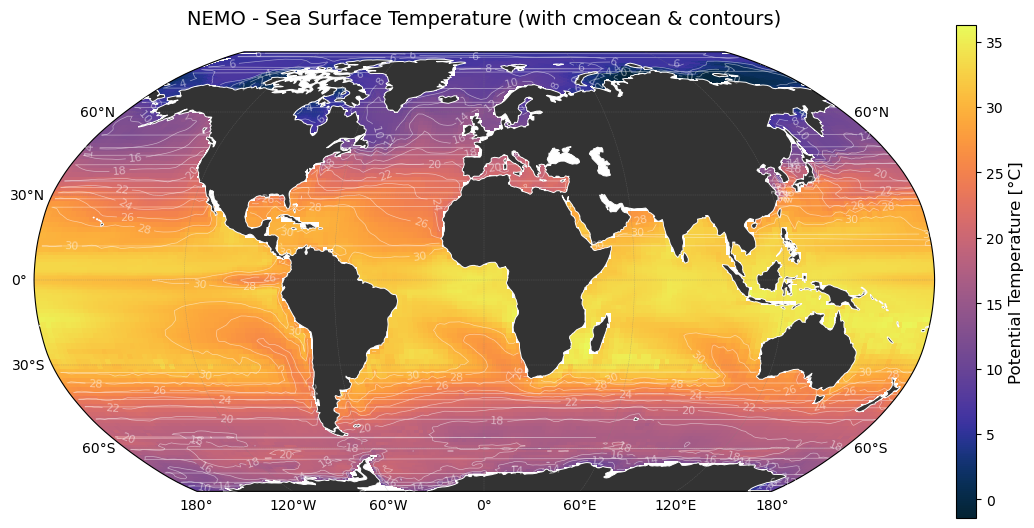

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean # https://matplotlib.org/cmocean/

from ecpost.core.io.reader import reader_nemo_field

ds = reader_nemo_field('csa0', 2000, 2000, 'thetao')
sst = ds.thetao.isel(z=0, time=0)

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())

# 1. Plot del campo di temperatura (shading)
# Usiamo pcolormesh per il fondo continuo
im = ax.pcolormesh(
    ds.lon, ds.lat, sst,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.thermal, 
    shading='auto'
)

# 2. Aggiunta dei Contour (linee di livello)
# Definiamo i livelli, ad esempio ogni 2 gradi
levels = range(-2, 32, 2)
contours = ax.contour(
    ds.lon, ds.lat, sst,
    levels=levels,
    colors='white',
    linewidths=0.5,
    alpha=0.5,
    transform=ccrs.PlateCarree()
)
# Etichette sulle linee (opzionale)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# 3. Estetica professionale
ax.add_feature(cfeature.LAND, facecolor='#333333', zorder=2) # Terra scura per contrasto
ax.coastlines(resolution='110m', color='white', linewidth=0.7, zorder=3)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cb = plt.colorbar(im, orientation='vertical', pad=0.02, aspect=25, shrink=0.8)
cb.set_label('Potential Temperature [°C]', fontsize=12)

plt.title('NEMO - Sea Surface Temperature (with cmocean & contours)', fontsize=14, pad=20)
plt.show()

In [ ]:
import cmocean

cmocean.plots.plot_gallery()